<a id="start"></a>

<center>
<img src="assets/shad-logo.png" width="360"><br>
Python 2026<br><br>
<b style="font-size: 2em">NumPy, pandas, Polars</b><br><br>
От чисел и CSV к ответу на вопрос<br><br>
Абасов Ислам
</center>

## План

1. [Зачем нужны три библиотеки](#why)
2. [NumPy: считаем над массивами](#numpy)
3. [pandas: превращаем CSV в отчёт](#pandas)
4. [Polars: описываем вычисление и его план](#polars)
5. [Как выбрать инструмент](#choice)

Дополнительные темы: [Parquet](#parquet), [оконные функции](#windows),
[попарные расстояния](#distances).

[Шпаргалка](#reference)

<a id="why"></a>

## Когда данных становится много

Представьте, что вам прислали таблицу с результатами эксперимента,
выгрузку заказов или логи приложения. Данные уже есть — теперь нужно в них разобраться.

Обычно по ходу возникают похожие задачи:

- **Посчитать:** найти средние значения, сравнить измерения, перевести величины в другие единицы.
- **Разобраться:** проверить пропуски, выбрать нужные строки и сравнить группы — например, стоимость билетов в разных классах.
- **Повторить:** получить такой же отчёт по новой выгрузке, не собирая его каждый раз вручную.

Сегодня посмотрим, как NumPy, pandas и Polars помогают с этой работой.

## Почему недостаточно списка словарей?

Списками и циклами можно решить все эти задачи.
Но придётся вручную поддерживать форму данных, группировки и обработку пропусков.

**NumPy** даёт числовой массив и операции над ним.
**pandas** добавляет таблицу, названия столбцов и индекс.
**Polars** позволяет описывать табличные вычисления выражениями и строить план запроса.

Меньше ручной работы — проще увидеть смысл вычисления и проверить результат.

In [1]:
from pathlib import Path
from timeit import repeat

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display

# Запускаем ноутбук из каталога lecture; все данные лежат рядом.
CSV = Path("titanic.csv")
print(f"NumPy {np.__version__} · pandas {pd.__version__} · Polars {pl.__version__}")

NumPy 2.5.2 · pandas 3.0.5 · Polars 1.44.2


<a id="numpy"></a>

## NumPy и его основной объект — ndarray

В основе NumPy лежит **`ndarray` — многомерный массив**.
Это объект, который хранит данные и позволяет выполнять над ними вычисления.

Начнём с простого случая: длительности трёх сессий в секундах.
Их можно записать в список Python, а из списка создать массив с помощью `np.array`.

У массива есть тип элементов (`dtype`), форма (`shape`) и число осей (`ndim`).
Посмотрим, как они выглядят у одномерного массива.

In [2]:
seconds = np.array([60, 120, 180], dtype=np.float64)
print(seconds)
print(type(seconds))
print("shape:", seconds.shape, "ndim:", seconds.ndim, "dtype:", seconds.dtype)

[ 60. 120. 180.]
<class 'numpy.ndarray'>
shape: (3,) ndim: 1 dtype: float64


### Что даёт нам массив?

Допустим, длительности нужны в минутах. Для списка мы делили бы каждый элемент на 60.
С массивом можно записать `seconds / 60` — операция применяется ко всем элементам.

Такой способ работы называют **векторизацией**: мы описываем операцию над целым массивом.
Для числовых типов данные хранятся компактно, а готовые операции выполняются в нативном коде,
без вызова Python для каждого элемента. На больших массивах это часто даёт ускорение.

In [3]:
python_seconds = [60, 120, 180]
python_minutes = [value / 60 for value in python_seconds]
numpy_minutes = seconds / 60

print("Список:", python_minutes)
print("Массив:", numpy_minutes)

Список: [1.0, 2.0, 3.0]
Массив: [1. 2. 3.]


### А если у каждой сессии несколько измерений?

До сих пор мы хранили только длительность. Добавим число событий в каждой сессии.
Получится двумерный массив: **строка — сессия, столбец — измеряемый признак**.

Запишем три сессии с двумя признаками. Shape такого массива — `(3, 2)`:
первая ось соответствует строкам, вторая — столбцам.
Все элементы по-прежнему имеют один `dtype`.

In [4]:
# Столбцы: длительность в секундах, число событий.
x = np.array([[60, 100], [120, 200], [180, 600]], dtype=np.float64)
print(x)
print("shape:", x.shape, "ndim:", x.ndim, "dtype:", x.dtype)

[[ 60. 100.]
 [120. 200.]
 [180. 600.]]
shape: (3, 2) ndim: 2 dtype: float64


### Выберем часть измерений

Теперь можно взять одну сессию, один признак или сессии, удовлетворяющие условию.
В записи `x[строки, столбцы]` первая позиция относится к строкам, вторая — к столбцам.
Двоеточие означает «взять всё вдоль этой оси».

Выберем длительности, а затем оставим только сессии не короче двух минут.
Условие создаст **маску** — массив значений `True` и `False`.

In [5]:
print("Первая сессия:", x[0])
print("Длительности:", x[:, 0])
mask = x[:, 0] >= 120
print("Маска:", mask)
print("Сессии от двух минут:")
print(x[mask])

Первая сессия: [ 60. 100.]
Длительности: [ 60. 120. 180.]
Маска: [False  True  True]
Сессии от двух минут:
[[120. 200.]
 [180. 600.]]


### Выбрали часть массива — получили копию?

Не всегда. Обычный срез NumPy разделяет память с исходным массивом:
изменение среза затронет и исходные данные.

Это позволяет не копировать большие массивы при каждом выборе строк.
Если выбранные данные нужно менять независимо, используйте `.copy()`.
Выбор по булевой маске, в отличие от обычного среза, создаёт копию.

In [6]:
sample = x.copy()
view = sample[:2]
view[0, 0] = -1
print("После изменения среза:", sample[0, 0])
independent = sample[:2].copy()
independent[0, 0] = 999
print("После изменения копии:", sample[0, 0])

После изменения среза: -1.0
После изменения копии: -1.0


In [7]:
# Обычный срез разделяет память с исходным массивом.
mask_example = np.array([10, 20, 30])
part = mask_example[:2]
part[0] = 99

print("Срез:", part)
print("Исходный массив:", mask_example)

Срез: [99 20]
Исходный массив: [99 20 30]


In [8]:
# Результат отбора по маске — независимая копия.
mask_example = np.array([10, 20, 30])
part = mask_example[mask_example >= 20]
part[0] = 99

print("Копия:", part)                     
print("Исходный массив:", mask_example)

Копия: [99 30]
Исходный массив: [10 20 30]


In [9]:
# Присваивание по маске меняет сам исходный массив.
mask_example = np.array([10, 20, 30])
mask_example[mask_example >= 20] = 99

print("Исходный массив:", mask_example)  # [10 99 99]

Исходный массив: [10 99 99]


### От отдельных сессий — к общим характеристикам

Вернёмся к нашим измерениям. Хотим понять, насколько каждая сессия отличается от средней
по длительности и по числу событий. Сначала найдём среднее каждого столбца.

Для этого нужно указать **ось, вдоль которой собираем значения**:

- `axis=0`: усредняем по сессиям → остаётся среднее каждого признака.
- `axis=1`: усредняем по признакам → остаётся число для каждой сессии.

Нам нужен первый вариант. Смешивать секунды и количество событий в одном среднем здесь бессмысленно.

In [10]:
column_means = x.mean(axis=0)
print("Средняя длительность и среднее число событий:", column_means)
print("Форма результата:", column_means.shape)

Средняя длительность и среднее число событий: [120. 300.]
Форма результата: (2,)


### Вычтем средние из каждой строки

Теперь у нас есть два средних — по одному на признак.
Чтобы получить отклонения, вычтем их из каждой сессии: `x - column_means`.
Такое преобразование называют **центрированием**.

NumPy сам применит вектор средних к каждой строке. Этот механизм называется **broadcasting**.

```text
измерения: (3, 2)
средние:      (2,)
отклонения:(3, 2)
```

Размеры сравниваются справа налево: они должны совпадать или один из них должен быть `1`.

In [11]:
centered = x - column_means
print(centered)
print("Проверка средних:", centered.mean(axis=0))

[[ -60. -200.]
 [   0. -100.]
 [  60.  300.]]
Проверка средних: [0. 0.]


### Вопрос: как указать другую ось?

Мы вычитали одну поправку для каждого столбца. Теперь посмотрим на форму массива отдельно от смысла измерений:
пусть нужно вычесть по одному числу из каждой строки.

У `x` форма `(3, 2)`, у поправок — `(3,)`.
Сработает ли `x - offsets`? Как превратить поправки в столбец формы `(3, 1)`?

Сопоставьте размеры справа налево, прежде чем запускать код.

In [12]:
offsets = np.array([1, 2, 3])
print("Столбец поправок:", offsets[:, None].shape)
print(x - offsets[:, None])

Столбец поправок: (3, 1)
[[ 59.  99.]
 [118. 198.]
 [177. 597.]]


In [13]:
offsets, offsets.shape

(array([1, 2, 3]), (3,))

In [14]:
offsets[:], offsets.shape

(array([1, 2, 3]), (3,))

In [15]:
offsets[None, :, None], offsets[None, :, None].shape

(array([[[1],
         [2],
         [3]]]),
 (1, 3, 1))

### От поэлементных операций к линейной алгебре

Деление и вычитание выше работали поэлементно. Так же работает `*`.
Но иногда нужно объединить признаки в одно число — например, посчитать взвешенную сумму для каждой сессии.

Для этого есть `@`: матричное умножение. Сначала сравним результат `x * weights` и `x @ weights`.
Веса в этом примере условные.

В линейной алгебре также часто меняют форму массива: `reshape` сохраняет число элементов,
а `.T` транспонирует матрицу.

In [16]:
print(x)

[[ 60. 100.]
 [120. 200.]
 [180. 600.]]


In [17]:
weights = np.array([0.5, 0.01])
print("Взвешенные признаки:\n", x * weights)
print("Сумма для каждого объекта:", x @ weights)

Взвешенные признаки:
 [[30.  1.]
 [60.  2.]
 [90.  6.]]
Сумма для каждого объекта: [31. 62. 96.]


In [18]:
arr = np.arange(6)
print(arr, arr.shape)
arr = arr.reshape(3,2)
print(arr, arr.shape)

[0 1 2 3 4 5] (6,)
[[0 1]
 [2 3]
 [4 5]] (3, 2)


In [19]:
# reshape не меняет число элементов: из шести нельзя получить семь.
try:
    arr.reshape(1, 7)
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: cannot reshape array of size 6 into shape (1,7)


In [20]:
arr

array([[0, 1],
       [2, 3],
       [4, 5]])

In [21]:
arr.T

array([[0, 2, 4],
       [1, 3, 5]])

### Измерим скорость операции над массивом

Мы переводили длительности из секунд в минуты. Теперь сравним время той же операции
для списка Python и массива NumPy — 41 замер от 10 до миллиона элементов.
Точки распределены равномерно по логарифмической шкале.

В обоих случаях входные данные готовы заранее, а результат создаётся заново при каждом вызове.
Перед замером проверим, что ответы совпадают.

In [22]:
from timeit import Timer


def minutes_python(values):
    return [value / 60 for value in values]


def minutes_numpy(values):
    return values / 60


def time_per_call(operation):
    timer = Timer(operation)
    calls = 1
    while timer.timeit(number=calls) < 0.03:
        calls *= 2
    return min(timer.repeat(repeat=3, number=calls)) / calls

In [23]:
from tqdm.auto import tqdm

sizes = np.unique(np.geomspace(10, 1_000_000, 41).astype(int))
python_times, numpy_times = [], []

with tqdm(total=2 * len(sizes), desc="Замеры", unit="замер") as progress:
    for size in sizes:
        array_values = np.arange(size, dtype=np.float64)
        list_values = array_values.tolist()
        np.testing.assert_allclose(minutes_python(list_values), minutes_numpy(array_values))
        python_times.append(time_per_call(lambda: minutes_python(list_values)))
        progress.update(1)
        numpy_times.append(time_per_call(lambda: minutes_numpy(array_values)))
        progress.update(1)

speedups = np.array(python_times) / np.array(numpy_times)
print(f"Измерено размеров: {len(sizes)}; диапазон: {sizes[0]:,}–{sizes[-1]:,} элементов")

Замеры:   0%|          | 0/82 [00:00<?, ?замер/s]

Измерено размеров: 41; диапазон: 10–1,000,000 элементов


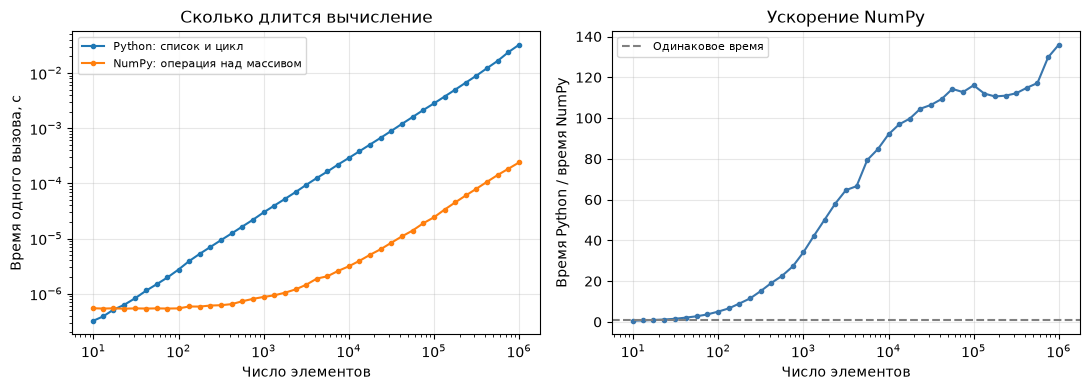

In [24]:
fig, (time_ax, speed_ax) = plt.subplots(1, 2, figsize=(11, 4))
time_ax.loglog(sizes, python_times, "o-", markersize=3, label="Python: список и цикл")
time_ax.loglog(sizes, numpy_times, "o-", markersize=3, label="NumPy: операция над массивом")
time_ax.set(xlabel="Число элементов", ylabel="Время одного вызова, с", title="Сколько длится вычисление")
time_ax.legend(fontsize=8)
speed_ax.semilogx(sizes, speedups, "o-", markersize=3, color="#3976ad")
speed_ax.axhline(1, color="gray", linestyle="--", label="Одинаковое время")
speed_ax.set(xlabel="Число элементов", ylabel="Время Python / время NumPy", title="Ускорение NumPy")
speed_ax.legend(fontsize=8)
for ax in (time_ax, speed_ax):
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Как читать этот график

Слева — время вычисления: чем ниже, тем быстрее. Справа — отношение времени Python к NumPy:
выше `1` означает, что NumPy быстрее, ниже `1` — что быстрее Python.

На маленьких массивах существенны накладные расходы вызова.
На больших сильнее проявляется разница между Python-циклом и нативной операцией.
Форма кривой зависит также от выделения памяти, кэшей и нагрузки компьютера.

Это замер одной операции на этом компьютере. Преобразование списка в массив сюда не входит;
при повторном запуске точки могут измениться.

<a id="pandas"></a>

## pandas: работаем с таблицей

В NumPy мы хранили числовые измерения. В таблице рядом могут оказаться возраст, имя и номер билета.
`DataFrame` хранит такие столбцы вместе и позволяет обращаться к ним по названию.

Прочитаем Titanic. Каждая строка — пассажир, каждый столбец — его характеристика.
Сначала посмотрим несколько строк, затем научимся выбирать пассажиров и считать статистику.

In [25]:
df = pd.read_csv(CSV)
df.head(5)

,PassengerId,Survived,Pclass,Lname,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,Braund,Mr. Owen Harris,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,Cumings,Mrs. John Bradley (Florence Briggs Thayer),female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,Heikkinen,Miss. Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,Futrelle,Mrs. Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,Allen,Mr. William Henry,male,35.0,0,0,373450,8.0500,NaN,S


### Посмотрим, что загрузилось

`shape` показывает число строк и столбцов, `dtypes` — типы данных.
Для начала нам понадобятся класс билета (`Pclass`), пол (`Sex`), возраст (`Age`) и цена (`Fare`).

In [26]:
print("Размер таблицы:", df.shape)
df[["Pclass", "Sex", "Age", "Fare"]].dtypes

Размер таблицы: (156, 13)


Pclass      int64
Sex           str
Age       float64
Fare      float64
dtype: object

### Один столбец или таблица из одного столбца?

`df["Age"]` возвращает `Series` — столбец с индексом.
`df[["Age"]]` возвращает `DataFrame`: мы передали список названий, хотя в нём всего одно имя.

In [27]:
display(df["Age"].head(5))
display(df[["Age"]].head(5))

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


### Выберем пассажирок

Сравнение столбца со строкой создаёт булеву маску, как в NumPy.
Сначала посмотрим на неё, затем используем для отбора строк.

In [28]:
female = df["Sex"] == "female"
female.head(5)

0    False
1     True
2     True
3     True
4    False
Name: Sex, dtype: bool

In [29]:
df[female].head(5)

,PassengerId,Survived,Pclass,Lname,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,Cumings,Mrs. John Bradley (Florence Briggs Thayer),female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,Heikkinen,Miss. Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,Futrelle,Mrs. Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,Johnson,Mrs. Oscar W (Elisabeth Vilhelmina Berg),female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,Nasser,Mrs. Nicholas (Adele Achem),female,14.0,1,0,237736,30.0708,NaN,C


### Добавим второе условие

Оставим пассажирок старше 30 лет.
`&` объединяет два условия поэлементно; каждое условие заключаем в скобки.

In [30]:
selected = (df["Sex"] == "female") & (df["Age"] > 30)
df.loc[selected, ["Name", "Age", "Fare"]].head(5)

,Name,Age,Fare
1,Mrs. John Bradley (Florence Briggs Thayer),38.0,71.2833
3,Mrs. Jacques Heath (Lily May Peel),35.0,53.1000
11,Miss. Elizabeth,58.0,26.5500
15,Mrs. (Mary D Kingcome),55.0,16.0000
18,Mrs. Julius (Emelia Maria Vandemoortele),31.0,18.0000


### loc — метка, iloc — позиция

Отсортируем пассажиров по возрасту. Метки индекса сохранятся, а позиции строк изменятся.

`iloc[0]` — первая строка после сортировки.
`loc[78]` — строка с меткой `78`, где бы она теперь ни находилась.

In [31]:
by_age = df.sort_values("Age", ascending=False)
by_age[["Age", "Fare"]].head(3)

,Age,Fare
96,71.0,34.6542
116,70.5,7.7500
33,66.0,10.5000


In [32]:
display(by_age.iloc[0][["Age", "Fare"]])
display(by_age.loc[78, ["Age", "Fare"]])

Age        71.0
Fare    34.6542
Name: 96, dtype: object

Age      0.83
Fare    29.00
Name: 78, dtype: float64

### Индекс может состоять из строк

Создадим небольшой `Series` с названиями цветов.
По метке `Red` и по позиции `0` мы здесь получим одно и то же значение.

In [33]:
colors = pd.Series([1, 2, 3], index=["Red", "Green", "Blue"])
display(colors)
print(colors.loc["Red"], colors.iloc[0])

Red      1
Green    2
Blue     3
dtype: int64

1 1


### При вычислении pandas сопоставляет метки

В этих двух столбцах метки расположены в разном порядке.
Значение для `A` сложится со значением для `A`, а не с первой строкой второго столбца.
Для `C` пары нет — получится пропуск.

In [34]:
base = pd.Series([10, 20, 30], index=["A", "B", "C"])
extra = pd.Series([2, 1], index=["B", "A"])
base + extra

A    11.0
B    22.0
C     NaN
dtype: float64

### Изменение выбранных строк

Для примера увеличим цену билета у пассажиров в возрасте 20, 25 и 30 лет.
`isin` проверяет принадлежность списку, а `loc` указывает ячейки для изменения.
Работаем с копией, чтобы следующие примеры использовали исходные цены.

В pandas 3 изменение отдельной производной таблицы не меняет исходную (Copy-on-Write).
Если хотим изменить `example`, присваиваем именно в `example.loc[...]`.

In [35]:
example = df.copy()
selected = example["Age"].isin([20, 25, 30])
example.loc[selected, "Fare"] *= 10
example.loc[selected, ["Age", "Fare"]].head(3)

,Age,Fare
12,20.0,80.50
75,25.0,76.50
79,30.0,124.75


### Пропуски: посмотрим на номера кают

Номер каюты известен не для каждого пассажира.
`isna()` показывает, где значения нет. Это не то же самое, что пустая строка или ноль.

In [36]:
cabins = df["Cabin"].head(8)
display(cabins)
display(cabins.isna())

0     NaN
1     C85
2     NaN
3    C123
4     NaN
5     NaN
6     E46
7     NaN
Name: Cabin, dtype: str

0     True
1    False
2     True
3    False
4     True
5     True
6    False
7     True
Name: Cabin, dtype: bool

### Удалить пропуски или заменить?

`dropna()` оставит только известные каюты, `fillna("unknown")` сохранит все строки и заменит пропуски.
Сравните длину и индекс результатов. Сам столбец `cabins` эти вызовы не меняют.

Для числовых данных подстановка нуля может изменить смысл статистики.

In [37]:
display(cabins.dropna())
display(cabins.fillna("unknown"))

1     C85
3    C123
6     E46
Name: Cabin, dtype: str

0    unknown
1        C85
2    unknown
3       C123
4    unknown
5    unknown
6        E46
7    unknown
Name: Cabin, dtype: str

### Вопрос: сколько значений участвует в среднем?

Для `[10, пропуск, 30]` различаются число строк (`size`) и число известных значений (`count`).
Что произойдёт со средним, если пропуск заменить нулём?

In [38]:
prices = pd.Series([10.0, None, 30.0])
print("Строк:", prices.size)
print("Известных цен:", prices.count())
print("Среднее:", prices.mean())
print("После замены пропуска нулём:", prices.fillna(0).mean())

Строк: 3
Известных цен: 2
Среднее: 20.0
После замены пропуска нулём: 13.333333333333334


### Средний возраст в каждом классе

Это можно посчитать отдельно для первого, второго и третьего класса.
Но формула каждый раз одна и та же — меняется только условие.

In [39]:
print("Первый класс:", df.loc[df["Pclass"] == 1, "Age"].mean())
print("Второй класс:", df.loc[df["Pclass"] == 2, "Age"].mean())
print("Третий класс:", df.loc[df["Pclass"] == 3, "Age"].mean())

Первый класс: 38.111111111111114
Второй класс: 28.114827586206893
Третий класс: 24.307142857142857


### groupby убирает повторение

`groupby("Pclass")` делит пассажиров на группы по классу.
Затем выбираем `Age` и считаем среднее отдельно внутри каждой группы.
Пропущенные значения возраста в среднее не входят.

In [40]:
df.groupby("Pclass")["Age"].mean()

Pclass
1    38.111111
2    28.114828
3    24.307143
Name: Age, dtype: float64

### Можно группировать по нескольким признакам

Добавим пол пассажира. Теперь одна строка результата соответствует паре «класс, пол».
`as_index=False` оставляет ключи группировки обычными столбцами.
Словарь в `agg` говорит: для столбца `Age` посчитать `mean`.

In [41]:
df.groupby(["Pclass", "Sex"], as_index=False).agg({"Age": "mean"})

,Pclass,Sex,Age
0,1,female,35.250000
1,1,male,39.315789
2,2,female,24.625000
3,2,male,30.578235
4,3,female,21.203704
5,3,male,26.255814


### Соединение таблиц: какие ключи совпали?

Чтобы понять `merge`, возьмём две таблицы всего по две строки.
В левой есть ключи `A` и `B`, в правой — `B` и `C`.

`on="key"` задаёт столбец для сопоставления. Позиции строк здесь не важны.

In [42]:
left = pd.DataFrame({"key": ["A", "B"], "value": [1, 2]})
right = pd.DataFrame({"key": ["B", "C"], "value": [3, 4]})
display(left)
display(right)

,key,value
0,A,1
1,B,2


,key,value
0,B,3
1,C,4


### inner и left отвечают на разные вопросы

`inner` оставит только общий ключ `B`.
`left` сохранит оба ключа левой таблицы; для `A` значения справа не найдётся.

Оба исходных столбца называются `value`, поэтому pandas добавит суффиксы `_x` и `_y`.
Если ключ справа повторяется, строк результата может стать больше.
Когда справа ожидается справочник, это можно проверить через `validate="many_to_one"`.

In [43]:
display(left.merge(right, on="key", how="inner"))
display(left.merge(right, on="key", how="left"))

,key,value_x,value_y
0,B,2,3


,key,value_x,value_y
0,A,1,NaN
1,B,2,3.0


### Быстро посмотреть распределение на графике

Вернёмся к Titanic. Гистограмма показывает, какие значения встречаются чаще.
У `Series` есть готовый метод `hist`: для первого взгляда на данные не нужно вручную строить отчёт.

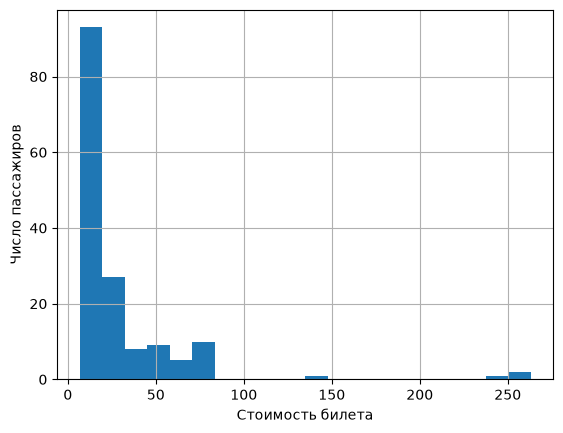

In [44]:
df["Fare"].hist(bins=20)
plt.xlabel("Стоимость билета")
plt.ylabel("Число пассажиров")
plt.show()

<a id="polars"></a>

## Polars: таблицы и выражения

Polars решает те же задачи: чтение данных, выбор строк, вычисление столбцов и группировка.
Здесь нет индекса pandas — ключи хранятся в обычных столбцах.

Сначала посмотрим знакомую таблицу пассажиров.
Затем разберём выражения на четырёх строках, чтобы результат каждой операции был виден целиком.

In [45]:
passengers = pl.read_csv(CSV)
passengers.select("Pclass", "Sex", "Age", "Fare").head(5)

Pclass,Sex,Age,Fare
i64,str,f64,f64
3,"""male""",22.0,7.25
1,"""female""",38.0,71.2833
3,"""female""",26.0,7.925
1,"""female""",35.0,53.1
3,"""male""",35.0,8.05


### Небольшая таблица для примеров

У каждой строки есть идентификатор `id`, числовое значение `value` и категория `category`.
Дальше будем менять только одну вещь за раз: выбирать строки, добавлять столбец, считать группы.

In [46]:
data = pl.DataFrame({
    "id": [1, 2, 3, 4],
    "value": [5, 15, 8, 20],
    "category": ["A", "B", "A", "B"],
})
data

id,value,category
i64,i64,str
1,5,"""A"""
2,15,"""B"""
3,8,"""A"""
4,20,"""B"""


### Выберем строки со значением больше 10

`pl.col("value")` описывает обращение к столбцу, а сравнение добавляет условие.
Получается выражение `Expr`, которое пока не содержит готовых строк.
`filter` применяет это условие к таблице.

In [47]:
condition = pl.col("value") > 10
print(type(condition).__name__)
data.filter(condition)

Expr


id,value,category
i64,i64,str
2,15,"""B"""
4,20,"""B"""


### Добавим удвоенное значение

`with_columns` вычисляет новый столбец, а `alias` даёт ему название.
Результат сохраняем в другую переменную; исходная `data` остаётся прежней.

In [48]:
double_value = (pl.col("value") * 2).alias("value_double")
with_double = data.with_columns(double_value)
with_double

id,value,category,value_double
i64,i64,str,i64
1,5,"""A""",10
2,15,"""B""",30
3,8,"""A""",16
4,20,"""B""",40


### Условие внутри столбца

Назовём значения больше 10 большими, остальные — маленькими.
`when → then → otherwise` читается как «если → то → иначе».
`pl.lit` означает строковое значение, а не название столбца.

In [49]:
size = (
    pl.when(pl.col("value") > 10)
    .then(pl.lit("big"))
    .otherwise(pl.lit("small"))
)
data.with_columns(size.alias("size"))

id,value,category,size
i64,i64,str,str
1,5,"""A""","""small"""
2,15,"""B""","""big"""
3,8,"""A""","""small"""
4,20,"""B""","""big"""


### Среднее внутри каждой категории

В категории `A` значения 5 и 8, в `B` — 15 и 20.
`group_by` собирает группы, а `agg` применяет выражение отдельно к каждой группе.
Сортируем результат, чтобы категории шли в понятном порядке.

In [50]:
category_means = data.group_by("category").agg(pl.col("value").mean())
category_means.sort("category")

category,value
str,f64
"""A""",6.5
"""B""",17.5


### Соединение по идентификатору

Добавим вторую маленькую таблицу с дополнительными сведениями.
У неё нет строки с `id=4`, зато есть `id=5`.

Левое соединение сохранит все строки `data`. Для `id=4` получится `null`,
а `id=5` в результат не попадёт. Это тот же принцип, что у `merge(..., how="left")` в pandas.

In [51]:
details = pl.DataFrame({
    "id": [1, 2, 3, 5],
    "extra_info": ["info1", "info2", "info3", "info4"],
})
data.join(details, on="id", how="left").sort("id")

id,value,category,extra_info
i64,i64,str,str
1,5,"""A""","""info1"""
2,15,"""B""","""info2"""
3,8,"""A""","""info3"""
4,20,"""B""",null


### null и NaN — разные значения

`None` превращается в `null`: значения нет. `NaN` — специальное значение типа float.
Посмотрим на них в двух отдельных столбцах.

In [52]:
missing = pl.DataFrame({
    "with_null": [1.0, None, 3.0],
    "with_nan": [1.0, float("nan"), 3.0],
})
missing

with_null,with_nan
f64,f64
1.0,1.0
null,NaN
3.0,3.0


### Для них нужны разные операции

`fill_null` заменяет только `null`, а `fill_nan` — только `NaN`.
Поэтому перед заполнением пропусков стоит проверить, что именно находится в данных.
`count` не учитывает `null`, но учитывает `NaN`.

In [53]:
display(missing.fill_null(-1))
display(missing.fill_nan(-2))

with_null,with_nan
f64,f64
1.0,1.0
-1.0,NaN
3.0,3.0


with_null,with_nan
f64,f64
1.0,1.0
null,-2.0
3.0,3.0


### Lazy: сначала описываем, потом выполняем

До сих пор операции выполнялись сразу. `scan_csv` позволяет собрать план обработки файла.
Вместо готовой таблицы получаем `LazyFrame`.

Выберем пассажиров старше 30 лет и оставим только возраст и цену билета.
Запишем операции отдельными шагами — все они пока только дополняют план.

In [54]:
source = pl.scan_csv(CSV)
older_passengers = source.filter(pl.col("Age") > 30)
query = older_passengers.select("Age", "Fare")

### Вопрос: что нужно для выполнения запроса?

Нужны ли движку имена, номера кают и классы билетов?
Где можно применить ограничение по возрасту?

`explain()` показывает план без получения полного результата.
Найдём в нём выбор столбцов и фильтр.

In [55]:
print(query.explain())

Csv SCAN [titanic.csv]
PROJECT 2/13 COLUMNS
SELECTION: col("Age") > 30.0
ESTIMATED ROWS: 171


### Теперь получим результат

`collect()` выполняет запрос и возвращает обычный `DataFrame`.

Оптимизатор может приблизить к чтению выбор столбцов (**projection pushdown**)
и фильтрацию (**predicate pushdown**).
Для CSV это не обещание пропустить все ненужные байты файла; формат источника тоже важен.

In [56]:
result = query.collect()
result.head(5)

Age,Fare
f64,f64
38.0,71.2833
35.0,53.1
35.0,8.05
54.0,51.8625
58.0,26.55


### Почему это может быть быстрее?

Готовые операции выполняются в нативном коде, многие могут использовать несколько потоков.
Lazy-план позволяет оптимизировать обработку целиком и сократить промежуточные данные.

pandas тоже использует быстрые нативные операции.
Преимущество зависит от задачи и размера данных — его нужно измерять, как мы делали с NumPy.

<a id="choice"></a>

## Что выбрать для следующей задачи?

| Задача | С чего начать |
|---|---|
| Числовые массивы, линейная алгебра, матрица признаков | NumPy |
| Исследование таблицы, индекс, существующий аналитический код | pandas |
| Табличный pipeline, выражения, оптимизируемый lazy-запрос | Polars |

Это совместимые части экосистемы. Выбор зависит также от команды,
библиотек вокруг и формата следующего шага обработки.

### Три идеи, которые стоит унести

1. **Форма и оси задают смысл числовой операции.** Сначала понимаем данные, потом убираем ручные циклы.
2. **Табличный отчёт — цепочка проверяемых преобразований.** Индекс, пропуски и ключи соединения влияют на ответ.
3. **Выражение позволяет описать вычисление до выполнения.** Полный план даёт движку возможность оптимизации.

**Вопросы?**

<a id="parquet"></a>

## Дополнительно · Parquet

CSV удобно посмотреть как текст, но при чтении приходится восстанавливать типы.
Parquet хранит схему и данные по столбцам, поддерживает сжатие.

Для регулярно пересчитываемого отчёта можно один раз подготовить Parquet,
а затем читать нужные столбцы. На маленьком файле не измеряем преимущество в скорости.

In [57]:
from tempfile import TemporaryDirectory

parquet_source = pl.read_csv(CSV)
with TemporaryDirectory() as temp_dir:
    parquet_path = Path(temp_dir) / "titanic.parquet"
    parquet_source.write_parquet(parquet_path)
    parquet_query = pl.scan_parquet(parquet_path).select("Pclass", "Embarked", "Fare")
    print(parquet_query.explain())
    parquet_result = parquet_query.collect()
parquet_result.head(3)

Parquet SCAN [/var/folders/vg/319lsf_53j35pg8nydxx9fjh0000gn/T/tmps2roqy4l/titanic.parquet]
PROJECT 3/13 COLUMNS
ESTIMATED ROWS: 156


Pclass,Embarked,Fare
i64,str,f64
3,"""S""",7.25
1,"""C""",71.2833
3,"""S""",7.925


<a id="windows"></a>

## Дополнительно · Окна

**Вопрос:** насколько цена каждого билета отличается от средней цены в его классе?

`group_by` сворачивает группу в строку результата.
Оконное выражение `.over(...)` возвращает групповой результат к каждой исходной строке.
Это удобно для сравнений внутри группы и ранжирования.

In [58]:
window_source = pl.read_csv(CSV)
window_result = window_source.with_columns(
    pl.col("Fare").mean().over("Pclass").alias("class_mean_fare"),
).with_columns(
    (pl.col("Fare") - pl.col("class_mean_fare")).alias("deviation_from_class"),
)
window_result.select("PassengerId", "Pclass", "Fare", "class_mean_fare", "deviation_from_class").head(5)

PassengerId,Pclass,Fare,class_mean_fare,deviation_from_class
i64,i64,f64,f64,f64
1,3,7.25,13.44006,-6.19006
2,1,71.2833,79.50194,-8.21864
3,3,7.925,13.44006,-5.51506
4,1,53.1,79.50194,-26.40194
5,3,8.05,13.44006,-5.39006


<a id="distances"></a>

## Дополнительно · Попарные расстояния

Сравним каждый объект одной группы с каждым объектом другой.
Используем `iris_subset.txt`: это условные учебные числа с названиями классов Iris,
а не реалистичные измерения цветов.

Мера — среднее абсолютное различие по четырём признакам.
В реальной задаче сначала нужно разобраться с масштабами и единицами признаков.

In [59]:
iris_demo = np.genfromtxt(
    "iris_subset.txt", delimiter=",", skip_header=1,
    dtype=None, encoding="utf-8", autostrip=True,
)
features = np.column_stack([iris_demo[f"f{i}"] for i in range(4)])
setosa = features[iris_demo["f4"] == "setosa"]
versicolor = features[iris_demo["f4"] == "versicolor"]
print("Группы:", setosa.shape, versicolor.shape)

Группы:

 (4, 4) (4, 4)


### Две оси объектов и одна ось признаков

```text
первая группа:  (A, 1, F)
вторая группа:  (1, B, F)
разности:      (A, B, F)
расстояния:    (A, B)      ← усредняем по признакам
```

Broadcasting не требует вручную размножать входы, но результат вычитания занимает память.
При 10 000 × 10 000 парах и 100 признаках один такой массив `float64` займёт около 80 ГБ.
Для больших данных нужны обработка блоками или специализированные алгоритмы.

In [60]:
differences = setosa[:, None, :] - versicolor[None, :, :]
distances = np.abs(differences).mean(axis=2)
print("Промежуточная форма:", differences.shape)
print("Матрица расстояний:\n", distances)

Промежуточная форма: (4, 4, 4)
Матрица расстояний:
 [[7.900000e+01 3.500000e+01 4.518750e+03 3.075000e+00]
 [7.090000e+02 6.665000e+02 4.382250e+03 6.345750e+02]
 [9.727750e+02 9.302750e+02 4.121975e+03 8.983500e+02]
 [2.672250e+02 2.247250e+02 4.637475e+03 2.516500e+02]]


<a id="reference"></a>

## Шпаргалка для самостоятельного чтения

| Действие | pandas | Polars |
|---|---|---|
| Выбрать столбцы | `df[["a", "b"]]` | `df.select("a", "b")` |
| Отобрать строки | `df.loc[df["a"] > 0]` | `df.filter(pl.col("a") > 0)` |
| Вычислить столбец | `df.assign(b=df["a"] + 1)` | `df.with_columns((pl.col("a") + 1).alias("b"))` |
| Среднее по группам | `df.groupby("g")["a"].mean()` | `df.group_by("g").agg(pl.col("a").mean())` |
| Соединить по ключу | `df.merge(other, on="id", how="left")` | `df.join(other, on="id", how="left")` |
| Сортировать | `df.sort_values("a")` | `df.sort("a")` |
| Заполнить пропуск | `df["a"].fillna(0)` | `pl.col("a").fill_null(0)` |
| Среднее группы в каждой строке | `df.groupby("g")["a"].transform("mean")` | `pl.col("a").mean().over("g")` |

Справа отдельные выражения применяются внутри `select` или `with_columns`.
Примеры не означают полного совпадения семантики индексов, пропусков и порядка строк.

### Что искать в документации по мере необходимости

- **NumPy:** `zeros`, `linspace`, `reshape`, `concatenate`, генератор `default_rng`, типы `numpy.typing`.
- **Таблицы:** строковые и временные операции, pivot/unpivot, скользящие окна.
- **Условия в Polars:** `pl.when(...).then(...).otherwise(...).alias(...)`; строковые литералы — `pl.lit(...)`.

[NumPy: broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) ·
[NumPy: копии и представления](https://numpy.org/doc/stable/user/basics.copies.html) ·
[pandas: начало работы](https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html) ·
[pandas: Copy-on-Write](https://pandas.pydata.org/docs/user_guide/copy_on_write.html) ·
[Polars: выражения](https://docs.pola.rs/user-guide/expressions/) ·
[Polars: lazy API](https://docs.pola.rs/user-guide/lazy/using/)